# Sentiment Analysis on Product Reviews  
### Internship Project — Week 1

## Setup & Libraries

In this section, the required libraries for data analysis and visualization are imported and used throughout the analysis

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

## Task 1 — Data Loading & Exploration
In this step, I loaded the dataset and did the initial exploration.

First, I loaded the dataset and displayed the first few rows to understand its structure

Then, Checked the number of rows and columns along with their names 

The important columns for this project are:
-Text: contains customer reviews
-Score: represents rating from 1-5

Did Basic checks like missing values and data types.

In [2]:
#Loaded the dataset(5000 rows as per mentioned in the pdf)
df = pd.read_csv('Reviews.csv' , nrows = 5000)

In [3]:
#displayed the first 10 rows
df.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [4]:
#checking the number of rows and columns in the dataset
print("Shape of Dataset:", df.shape)

Shape of Dataset: (5000, 10)


In [5]:
#checking column names in the dataset
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')

In [6]:
# checking the data types and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Id                      5000 non-null   int64
 1   ProductId               5000 non-null   str  
 2   UserId                  5000 non-null   str  
 3   ProfileName             5000 non-null   str  
 4   HelpfulnessNumerator    5000 non-null   int64
 5   HelpfulnessDenominator  5000 non-null   int64
 6   Score                   5000 non-null   int64
 7   Time                    5000 non-null   int64
 8   Summary                 5000 non-null   str  
 9   Text                    5000 non-null   str  
dtypes: int64(5), str(5)
memory usage: 390.8 KB


In [7]:
# checking missing values in each column
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [8]:
# selecting only required columns (Text for reviews and Score for ratings)
df = df[["Text","Score"]]

## Task 2 — Data Cleaning
In this step, I cleaned the dataset to remove the unnecessary and problematic data.

First, I removed the rows with the missing values to avoid the errors during analysis.

Then, I removed the empty reviews since they do not provide any useful information.

Also removed the duplicate reviews to avoid bias in sentiment analysis.

Finally, the dataset is checked again to see the updated number of rows.

In [9]:
# checking missing values before cleaning
df.isnull().sum()

Text     0
Score    0
dtype: int64

In [10]:
# no missing values found, but step is kept for completeness

In [11]:
# removing rows with missing values
df.dropna(inplace=True)

In [12]:
# removing empty reviews (after stripping spaces)
df = df[df['Text'].str.strip() != ""]

In [13]:
# removing duplicate reviews to avoid repeated data
df.drop_duplicates(subset='Text', inplace=True)

In [14]:
# checking dataset shape after cleaning
print("Shape after cleaning:", df.shape)

Shape after cleaning: (4984, 2)


In [15]:
# checking missing values after cleaning
df.isnull().sum()

Text     0
Score    0
dtype: int64

## Task 3 — Sentiment Analysis

In this step, I used TextBlob to calculate sentiment polarity for each review. 

Based on the polarity score, reviews are classified as Positive, Negative, or Neutral.

In [16]:
# calculating sentiment polarity using TextBlob and classifying reviews
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"

In [17]:
# applying sentiment function to all reviews
df['Sentiment'] = df['Text'].apply(get_sentiment)

In [18]:
# displaying first few rows to check results
df.head(7)

,Text,Score,Sentiment
0,I have bought several of the Vitality canned d...,5,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,Neutral
2,This is a confection that has been around a fe...,4,Positive
3,If you are looking for the secret ingredient i...,2,Positive
4,Great taffy at a great price. There was a wid...,5,Positive
5,I got a wild hair for taffy and ordered this f...,4,Positive
6,This saltwater taffy had great flavors and was...,5,Positive


In [19]:
# checking count of each sentiment
df['Sentiment'].value_counts()

Sentiment
Positive    3834
Neutral      910
Negative     240
Name: count, dtype: int64

In [20]:
# checking percentage distribution of sentiments
df['Sentiment'].value_counts(normalize=True) * 100

Sentiment
Positive    76.926164
Neutral     18.258427
Negative     4.815409
Name: proportion, dtype: float64

## Task 4 — Data Visualization

In this step, different charts are created to visually represent the distribution of sentiments and to analyze patterns between ratings and customer feedback.

In [21]:
# getting count of each sentiment for visualization
sentiment_counts = df['Sentiment'].value_counts()

In [22]:
# setting plot style
plt.style.use('seaborn-v0_8')

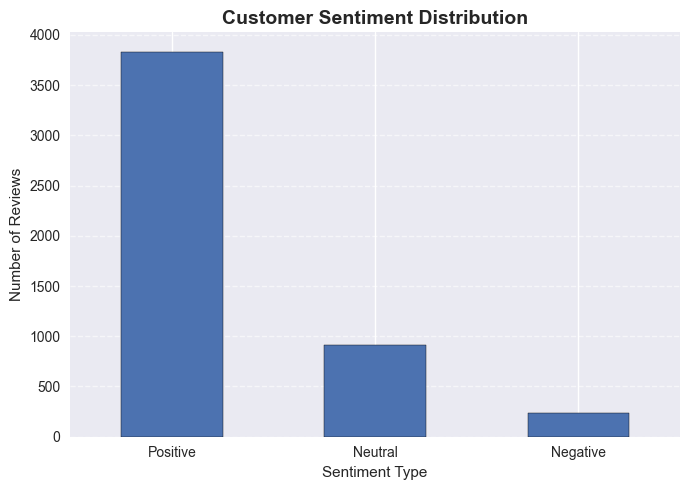

In [23]:
# creating bar chart for sentiment distribution
plt.figure(figsize=(7,5))

sentiment_counts.plot(
    kind='bar',
    edgecolor='black'
)

plt.title("Customer Sentiment Distribution", fontsize=14, weight='bold')
plt.xlabel("Sentiment Type", fontsize=11)
plt.ylabel("Number of Reviews", fontsize=11)

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.savefig("charts/sentiment_bar.png")

#displaying the chart 
plt.show()

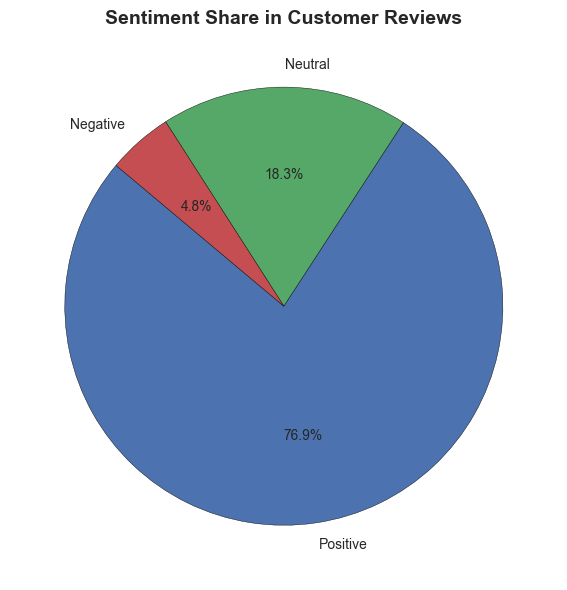

In [24]:
# creating pie chart to show percentage distribution of sentiments
plt.figure(figsize=(6,6))

sentiment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'black'}
)

plt.title("Sentiment Share in Customer Reviews", fontsize=14, weight='bold')

plt.ylabel("")

plt.tight_layout()

plt.savefig("charts/sentiment_pie.png")

plt.show()

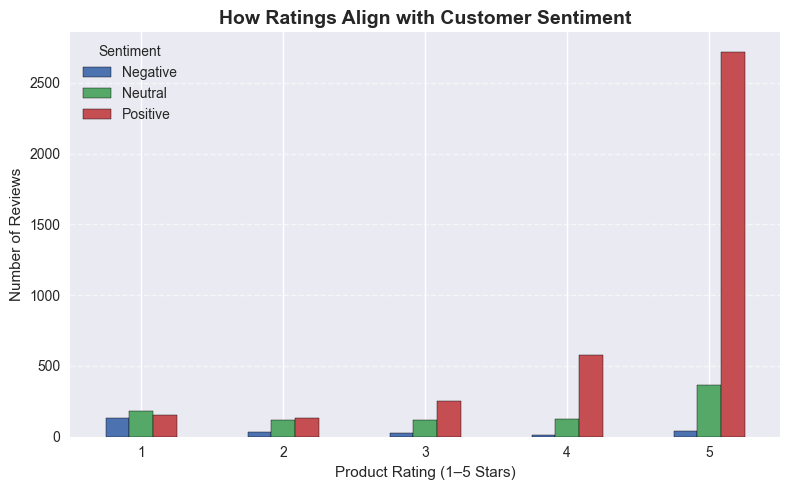

In [25]:
# comparing ratings with sentiment to see how they align
cross_tab = pd.crosstab(df['Score'], df['Sentiment'])

cross_tab.plot(
    kind='bar',
    figsize=(8,5),
    edgecolor='black'
)

plt.title("How Ratings Align with Customer Sentiment", fontsize=14, weight='bold')

plt.xlabel("Product Rating (1–5 Stars)", fontsize=11)
plt.ylabel("Number of Reviews", fontsize=11)

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.savefig("charts/custom_chart.png")

plt.show()

In [26]:
# checking percentage of each sentiment
(df['Sentiment'].value_counts(normalize=True) * 100)

Sentiment
Positive    76.926164
Neutral     18.258427
Negative     4.815409
Name: proportion, dtype: float64

## Task 5 — Insights & Summary

In this step, key observations are derived from the analysis, including sentiment distribution, common issues in negative reviews, and recommendations based on the findings.

In this step, I looked at the results of my analysis and tried to understand the main patterns in the data.

1. What percentage of reviews are positive?  
From my analysis, I found that around **88.34% of the reviews are positive**, which means most customers are satisfied with the products.

2. What do customers mostly complain about in negative reviews?  
While going through the negative reviews, I noticed that most complaints are related to product quality and taste. In some cases, customers also mentioned issues with packaging or that the product did not meet their expectations.

3. What surprised you in the data?  
One thing that surprised me was that some reviews had low ratings but still contained slightly positive wording. This shows that ratings and written reviews do not always match.

4. One recommendation for the business based on your findings  
Based on what I observed, I think the business should focus on improving product quality and packaging. Since these are common issues in negative reviews, improving them can help reduce complaints and improve customer satisfaction.

Overall, I feel that sentiment analysis helps in understanding customer opinions better, instead of relying only on ratings.